# PCA exploration of the CLUE active-learning trajectory

Visualise how novelty-driven selection explores chemical space over 10 CLUE iterations.
Each iteration picks the 10 most novel candidates from the target pool and promotes them to
the training set (MP-bandgap-1 → MP-bandgap-11).

**Embedding space:** 128-dim GNN embeddings extracted with the final run-11 model.  
**Dimensionality reduction:** 3-component PCA fitted on training + remaining target data.  
**Legend:**
- 🔵 initial training data (run 1)  
- 🔴 remaining target pool (end of run 11)  
- gradient coloured points: materials selected in each iteration (early = dark, late = bright)

## 1 · Imports and configuration

In [ ]:
import numpy             as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import json
import os

from sklearn.decomposition import PCA

import libraries.model   as clm
import libraries.dataset as cld

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paths ──────────────────────────────────────────────────────────────────────
N_RUNS      = 11
MODEL_RUNS  = [f'models/MP-bandgap-{i}'  for i in range(1, N_RUNS + 1)]
TARGET_RUN  = 'targets/MP-bandgap-11'
FINAL_MODEL = MODEL_RUNS[-1]          # run-11 model used for all embeddings

## 2 · Load run-11 model and reference dataset

In [2]:
# Reference dataset and standardisation parameters from the final run
# (all 7 556 training points, standardised with run-11 statistics)
ref_dataset_std = torch.load(
    f'{FINAL_MODEL}/ref_dataset_std.pt', weights_only=False
)
r_std_params = cld.load_json(f'{FINAL_MODEL}/standardized_parameters.json')

print(f'Run-11 reference dataset:  {len(ref_dataset_std):>6} materials')
print(f'Node feature dimension:    {ref_dataset_std[0].x.shape[1]}')

# Load the trained GNN model (run 11) in evaluation mode
model = clm.load_model(
    ref_dataset_std[0].num_node_features,
    pdropout=0,
    device=device,
    model_name=f'{FINAL_MODEL}/model.pt',
    mode='eval',
)
print('Model loaded successfully.')

Run-11 reference dataset:    7546 materials
Node feature dimension:    5
Model loaded successfully.


/home/claudio/cibran/Work/UPC/CLUE/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## 3 · Identify which materials were promoted in each iteration

For each consecutive pair of runs we find labels present in run *i+1* but absent in run *i*
(matching on composition + space-group, ignoring the float suffix in the label string).
This gives the 10 most-novel candidates selected at each iteration.

In [3]:
def material_key(label: str) -> str:
    """Stable identifier: first two whitespace-separated tokens (formula + spacegroup)."""
    return ' '.join(label.split()[:2])


# Load all reference dataset labels per run (labels only, no tensors kept in memory)
run_keys = {}
for i in range(1, N_RUNS + 1):
    d = torch.load(f'models/MP-bandgap-{i}/ref_dataset_std.pt', weights_only=False)
    run_keys[i] = {material_key(g.label) for g in d}
    print(f'  Run {i:>2}: {len(d):>5} materials in reference set')

# ── Assign each material in the run-11 reference set to the iteration it was promoted ──
# iteration 0  → present in run 1 (initial training data)
# iteration i  → first appeared when going from run i to run i+1  (i = 1 … 10)

label_to_iter: dict[str, int] = {}

for key in run_keys[1]:
    label_to_iter[key] = 0                       # original training data

for i in range(1, N_RUNS):                       # transitions 1→2, 2→3, …, 10→11
    newly_added = run_keys[i + 1] - run_keys[i]
    for key in newly_added:
        label_to_iter[key] = i
    print(f'  Transition {i}→{i+1}: {len(newly_added)} materials promoted')

# Map every data-point in the run-11 reference dataset to its iteration
iter_assignments = np.array(
    [label_to_iter.get(material_key(g.label), -1) for g in ref_dataset_std]
)

unknown = (iter_assignments == -1).sum()
if unknown:
    print(f'\n⚠ {unknown} materials not assigned to any iteration.')
else:
    print('\nAll materials assigned successfully.')

  Run  1:  7456 materials in reference set
  Run  2:  7466 materials in reference set
  Run  3:  7476 materials in reference set
  Run  4:  7486 materials in reference set
  Run  5:  7496 materials in reference set
  Run  6:  7506 materials in reference set
  Run  7:  7516 materials in reference set
  Run  8:  7526 materials in reference set
  Run  9:  7536 materials in reference set
  Run 10:  7546 materials in reference set
  Transition 1→2: 10 materials promoted
  Transition 2→3: 10 materials promoted
  Transition 3→4: 10 materials promoted
  Transition 4→5: 10 materials promoted
  Transition 5→6: 10 materials promoted
  Transition 6→7: 10 materials promoted
  Transition 7→8: 10 materials promoted
  Transition 8→9: 10 materials promoted
  Transition 9→10: 10 materials promoted

All materials assigned successfully.


## 4 · Load remaining target pool and re-standardise

The target pool (`targets/MP-bandgap-11`) is the evaluation set at the end of the last run.
We re-standardise it with run-11 statistics so the features are in the same space as the model expects.

In [4]:
# Load raw (un-standardised) target data then apply run-11 standardisation
target_raw = torch.load(f'{TARGET_RUN}/dataset.pt', weights_only=False)
target_std = cld.standardize_dataset_from_keys(target_raw, r_std_params)

print(f'Remaining target pool: {len(target_std):>4} materials')

Remaining target pool:  105 materials


## 5 · Extract GNN embeddings and apply 3-component PCA

In [5]:
from torch_geometric.loader import DataLoader as PyGDataLoader

def _extract_embeddings_cpu(dataset, model):
    """Extract 128-dim GNN embeddings, forcing CPU (avoids broken CUDA driver)."""
    model_cpu = model.module if hasattr(model, 'module') else model   # unwrap DataParallel
    model_cpu = model_cpu.cpu().eval()
    loader = PyGDataLoader(dataset, batch_size=128, shuffle=False)
    parts = []
    with torch.no_grad():
        for batch in loader:
            emb = model_cpu(batch.cpu(), return_graph_embedding=True).numpy()
            parts.append(emb)
    return np.concatenate(parts, axis=0)

print('Extracting embeddings for training data …')
emb_ref = _extract_embeddings_cpu(ref_dataset_std, model)

print('Extracting embeddings for remaining target pool …')
emb_tgt = _extract_embeddings_cpu(target_std, model)

# Fit PCA jointly so all points share the same coordinate system
emb_all = np.vstack([emb_ref, emb_tgt])
pca     = PCA(n_components=3, random_state=42)
coords  = pca.fit_transform(emb_all)

coords_ref = coords[:len(emb_ref)]
coords_tgt = coords[len(emb_ref):]

# Normalise each PC to unit variance so the 3D axes are on the same scale
pc_std = coords.std(axis=0)
coords_ref = coords_ref / pc_std

coords_tgt = coords_tgt / pc_std

evr = pca.explained_variance_ratio_
print(f'\nExplained variance — PC1: {evr[0]:.1%}  PC2: {evr[1]:.1%}  PC3: {evr[2]:.1%}')
print(f'Total: {evr.sum():.1%}')

Extracting embeddings for training data …
Extracting embeddings for remaining target pool …

Explained variance — PC1: 35.4%  PC2: 22.3%  PC3: 10.0%
Total: 67.7%


In [6]:
# ── Novelty relative to the run-1 training set (in run-11 embedding space) ─────
# Reference = run-1 training materials (7 456 points)
emb_run1_train = emb_ref[iter_assignments == 0]
emb_all_flat   = np.vstack([emb_ref, emb_tgt])   # 7 651 total

novelty_all = clm.estimate_novelty(emb_run1_train, emb_all_flat, method='kNN', n_neighbors=5)
novelty_ref = novelty_all[:len(emb_ref)]
novelty_tgt = novelty_all[len(emb_ref):]

# Map to marker area (pts²) — global min/max keeps a consistent visual scale
_nov_lo, _nov_hi = novelty_all.min(), novelty_all.max()

def _nov2size(nov, s_min=2, s_max=90):
    n = np.asarray(nov, dtype=float)
    return s_min + (s_max - s_min) * (n - _nov_lo) / (_nov_hi - _nov_lo + 1e-12)

size_ref = _nov2size(novelty_ref)
size_tgt = _nov2size(novelty_tgt)

print(f'Novelty  min={novelty_all.min():.3f}  median={np.median(novelty_all):.3f}'
      f'  max={novelty_all.max():.3f}')

Novelty  min=0.229  median=0.667  max=3.227


## 6 · Publication-ready 3D plot

Run the cell below to produce the figure.  
Adjust `VIEW_ELEV` / `VIEW_AZIM` to pick the best viewing angle before saving.

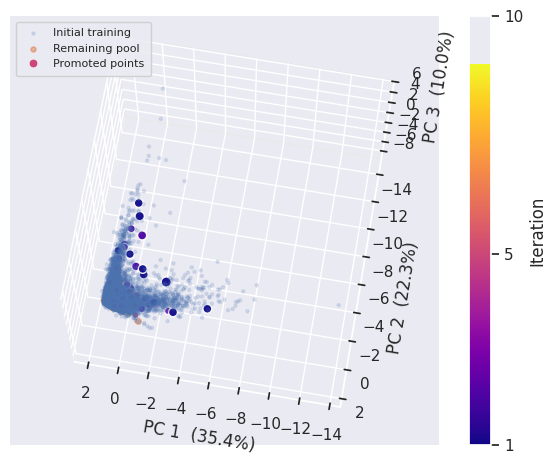

In [9]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (registers 3d projection)

# ── Viewing angle ──────────────────────────────────────────────────────────────
VIEW_ELEV  = 70    # elevation in degrees
VIEW_AZIM  = 100    # azimuth  in degrees

# ── Colour settings ────────────────────────────────────────────────────────────
C_TRAIN  = '#4C72B0'   # steel blue  – initial training
C_TARGET = '#DD8452'   # burnt orange – remaining target pool
CMAP_SEL = 'plasma'    # continuous colourmap for selected points

N_ITERS  = N_RUNS - 1  # 10 promotion steps
cmap_sel = mpl.colormaps[CMAP_SEL]
norm_sel = mcolors.Normalize(vmin=1, vmax=N_ITERS)

# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

# Remove grey pane backgrounds for a cleaner look
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linewidth=0.4)

# ── Layer 1: initial training data ────────────────────────────────────────────
mask_train = iter_assignments == 0
ax.scatter(
    coords_ref[mask_train, 0],
    coords_ref[mask_train, 1],
    coords_ref[mask_train, 2],
    c=C_TRAIN, alpha=0.15, s=5,
    label=f'Initial training',
    rasterized=True,
)

# ── Layer 2: remaining target pool ────────────────────────────────────────────
ax.scatter(
    coords_tgt[:, 0],
    coords_tgt[:, 1],
    coords_tgt[:, 2],
    c=C_TARGET, alpha=0.55, s=size_tgt,
    label=f'Remaining pool',
    rasterized=True,
)

# ── Layer 3: promoted points (one scatter per iteration for correct depth order)
for it in range(1, N_ITERS + 1):
    mask = iter_assignments == it
    if not mask.any():
        continue
    colour = cmap_sel(norm_sel(it))
    ax.scatter(
        coords_ref[mask, 0],
        coords_ref[mask, 1],
        coords_ref[mask, 2],
        color=colour,
        s=size_ref[mask], alpha=0.95,
        edgecolors='white',
        zorder=5,
    )

# ── Colourbar for selected points ─────────────────────────────────────────────
sm = mpl.cm.ScalarMappable(cmap=cmap_sel, norm=norm_sel)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Iteration')
cbar.set_ticks([1, 5, 10])

# ── Proxy artist so the promoted points appear in the legend ──────────────────
from matplotlib.lines import Line2D
proxy_sel = Line2D(
    [0], [0], linestyle='none', marker='o', markersize=6,
    markerfacecolor=cmap_sel(0.5), markeredgecolor='white',
    markeredgewidth=0.3, label=f'Promoted points',
)
handles, labels_ = ax.get_legend_handles_labels()
handles.append(proxy_sel)

ax.legend(handles=handles, loc='upper left', fontsize=8,
          framealpha=0.85, edgecolor='0.8', borderpad=0.6)

# ── Axis labels with explained variance ──────────────────────────────────────
ax.set_xlabel(f'PC 1  ({evr[0]:.1%})', labelpad=6)
ax.set_ylabel(f'PC 2  ({evr[1]:.1%})', labelpad=6)
ax.set_zlabel(f'PC 3  ({evr[2]:.1%})', labelpad=6)

ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)

fig.tight_layout()
plt.show()

## 7 · Save figure

Change `VIEW_ELEV` / `VIEW_AZIM` in the cell above to get the best angle, then run this cell.

In [8]:
OUT_PDF = 'pca_exploration.pdf'
OUT_PNG = 'pca_exploration.png'

fig.savefig(OUT_PDF, format='pdf', dpi=50, bbox_inches='tight')
fig.savefig(OUT_PNG, format='png', dpi=300, bbox_inches='tight')
print(f'Saved → {OUT_PDF}  and  {OUT_PNG}')

Saved → pca_exploration.pdf  and  pca_exploration.png
